# Generación Automática FEN

**DIEGO BESADA RODRÍGUEZ**

<div>
  <img src="images/fen.jpg"
       alt="FEN">
</div>

<div style="border:2px solid lightgreen; padding:10px; border-radius:5px; background-color:#ECFEEA;">
<strong>Estado:</strong> Terminado.
</div>

## Extracción de características

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.feature import hog
from skimage.filters import sobel
from scipy.ndimage import binary_fill_holes

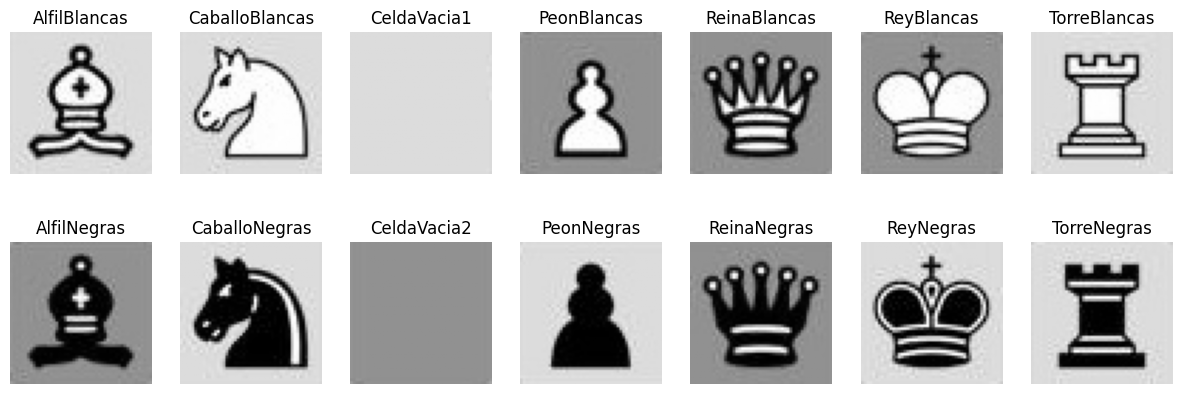

In [2]:
piezas = list(Path("Datasets/Datasets_image/Piezas").glob("*.jpeg"))

fig, axes = plt.subplots(2, len(piezas)//2, figsize=(15, 5))

for i, pieza in enumerate(sorted(piezas)):
    img = np.array(Image.open(pieza).convert("L"))
    piezas[i] = img
    
    globals()[pieza.stem] = img
    
    ax = axes[i % axes.shape[0], i // axes.shape[0]]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(pieza.stem)
    ax.axis('off')

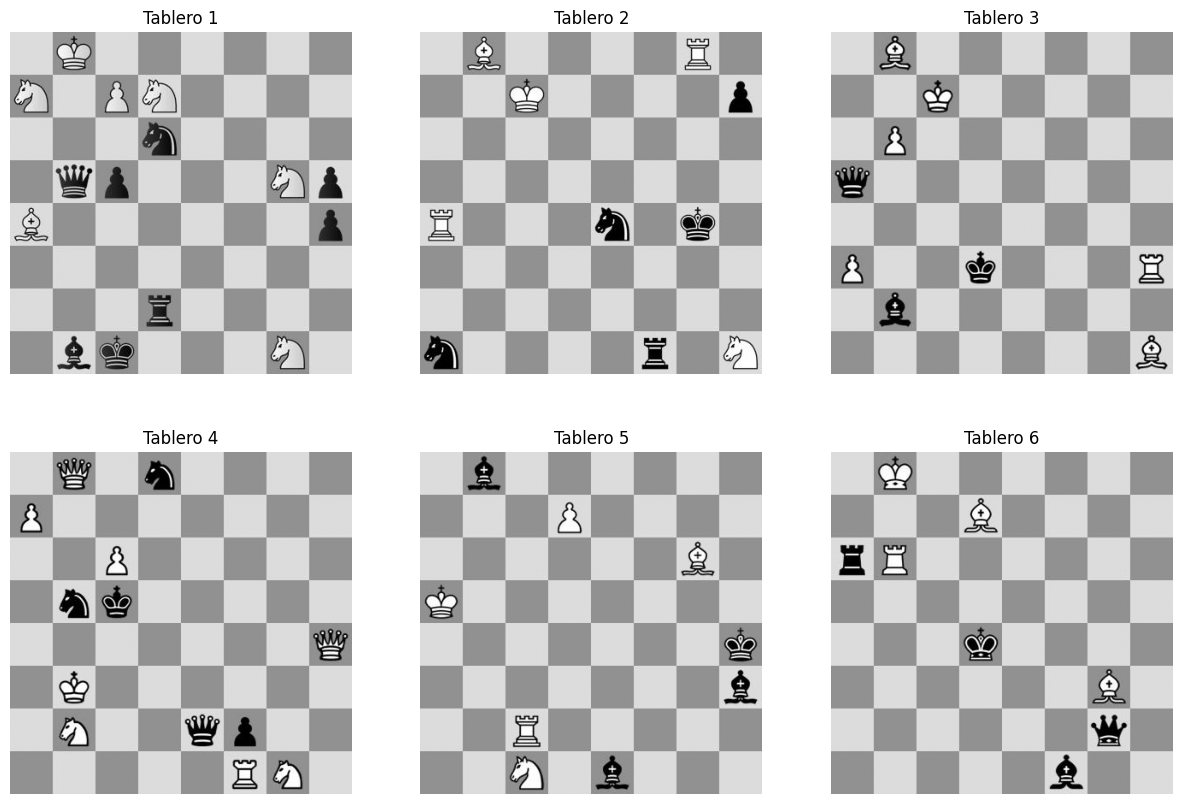

In [3]:
tableros = list(Path("Datasets/Datasets_image/Tableros").glob("*.jpeg"))
fen_tableros = tableros.copy()

fig, axes = plt.subplots(2, len(tableros)//2, figsize=(15, 10))

for i, tablero in enumerate(tableros):
    img = np.array(Image.open(tablero).convert("L"))
    tableros[i] = img

    ax = axes[i // axes.shape[1], i % axes.shape[1]]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Tablero {i+1}')
    ax.axis('off')

Vamos a ver los histogramas de las distintas piezas:

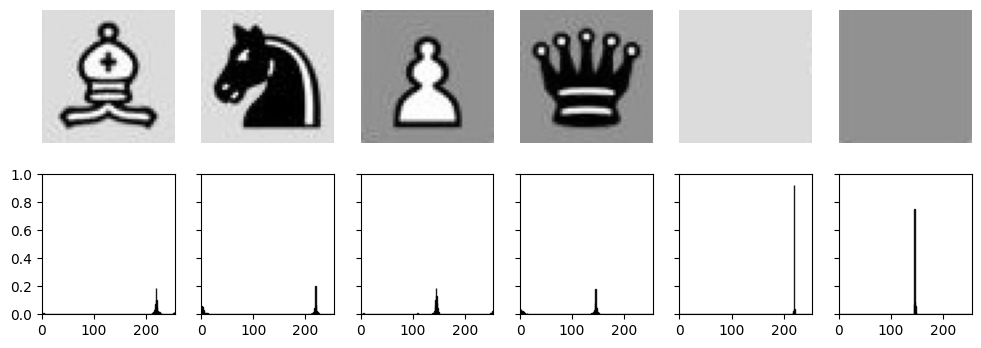

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4), sharey='row')

for i, img in enumerate([AlfilBlancas, CaballoNegras, PeonBlancas, ReinaNegras, CeldaVacia1, CeldaVacia2]):
    ax = axes[0, i % 6]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    ax2 = axes[1, i % 6]
    ax2.hist(
        img.ravel(),
        bins=256,
        range=(0, 255),
        color='dimgray',
        edgecolor='black',
        alpha=0.9,
        density=True
    )
    ax2.set_xlim(0, 255)
    ax2.set_ylim(0, 1)

Podemos ver como el color predominante es el de la celda y luego tenemos pequeños picos en el color de la pieza (y algo menor el el contrario). Con esto debería bastar para hacer un clasificador de color simple: comparar la zona alrededor del 0 con la de 255. Sin embargo, me gustaría hacer uno más robusto que pueda servir también en caso de que los colores de las celdas o de las piezas sean diferentes a los presentados en el problema.

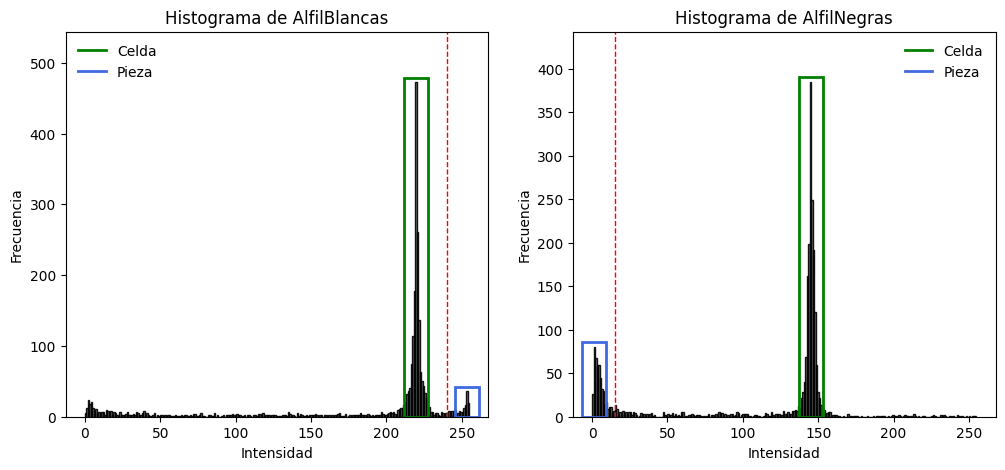

In [5]:
treshold_blancas = 240
treshold_negras = 15

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_b, bin_edges_b, _ = axes[0].hist(AlfilBlancas.ravel(), bins=256, color='dimgray', edgecolor='black', alpha=0.9)
axes[0].axvline(treshold_blancas, color='red', linestyle='dashed', linewidth=1)
axes[0].set_title('Histograma de AlfilBlancas')
axes[0].set_xlabel('Intensidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_ylim(0, max(counts_b) * 1.15)

peak_order_b = np.argsort(counts_b)[::-1]
cell_peak_b = peak_order_b[0]
piece_peak_b = next((idx for idx in peak_order_b[1:] if abs(idx - cell_peak_b) > 10), peak_order_b[1])
cell_x_b = (bin_edges_b[cell_peak_b] + bin_edges_b[cell_peak_b + 1]) / 2
piece_x_b = (bin_edges_b[piece_peak_b] + bin_edges_b[piece_peak_b + 1]) / 2
cell_y_b = counts_b[cell_peak_b]
piece_y_b = counts_b[piece_peak_b]
axes[0].add_patch(Rectangle((cell_x_b - 8, 0), width=16, height=cell_y_b + 6, fill=False, edgecolor='green', linewidth=2))
axes[0].add_patch(Rectangle((piece_x_b - 8, 0), width=16, height=piece_y_b + 6, fill=False, edgecolor='royalblue', linewidth=2))

counts_n, bin_edges_n, _ = axes[1].hist(AlfilNegras.ravel(), bins=256, color='dimgray', edgecolor='black', alpha=0.9)
axes[1].axvline(treshold_negras, color='red', linestyle='dashed', linewidth=1)
axes[1].set_title('Histograma de AlfilNegras')
axes[1].set_xlabel('Intensidad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_ylim(0, max(counts_n) * 1.15)

peak_order_n = np.argsort(counts_n)[::-1]
cell_peak_n = peak_order_n[0]
piece_peak_n = next((idx for idx in peak_order_n[1:] if abs(idx - cell_peak_n) > 10), peak_order_n[1])
cell_x_n = (bin_edges_n[cell_peak_n] + bin_edges_n[cell_peak_n + 1]) / 2
piece_x_n = (bin_edges_n[piece_peak_n] + bin_edges_n[piece_peak_n + 1]) / 2
cell_y_n = counts_n[cell_peak_n]
piece_y_n = counts_n[piece_peak_n]
axes[1].add_patch(Rectangle((cell_x_n - 8, 0), width=16, height=cell_y_n + 6, fill=False, edgecolor='green', linewidth=2))
axes[1].add_patch(Rectangle((piece_x_n - 8, 0), width=16, height=piece_y_n + 6, fill=False, edgecolor='royalblue', linewidth=2))

legend_handles = [
    Line2D([0], [0], color='green', lw=2, label='Celda'),
    Line2D([0], [0], color='royalblue', lw=2, label='Pieza')
]
axes[0].legend(handles=legend_handles, loc='upper left', frameon=False)
axes[1].legend(handles=legend_handles, loc='upper right', frameon=False)

plt.show()

In [6]:
THRESHOLD_BLANCAS = 240
THRESHOLD_NEGRAS = 15

def preprocess_image(pieza, return_all_steps=False, treshold_blancas=THRESHOLD_BLANCAS, treshold_negras=THRESHOLD_NEGRAS):
    edges = sobel(pieza)
    thr = np.percentile(edges, 75)
    mask = binary_fill_holes(edges > thr)
    pieza_pixels = pieza[mask]

    claros = pieza_pixels >= treshold_blancas
    oscuros = pieza_pixels < treshold_negras
    usar_claros = np.sum(claros) >= np.sum(oscuros)

    selected_mask = np.zeros_like(mask, dtype=bool)
    if usar_claros:
        selected_mask[mask] = pieza_pixels >= treshold_blancas
    else:
        selected_mask[mask] = pieza_pixels < treshold_negras

    selected_pixels = pieza[selected_mask]

    if return_all_steps:
        return edges, mask, selected_mask, selected_pixels

    return selected_pixels

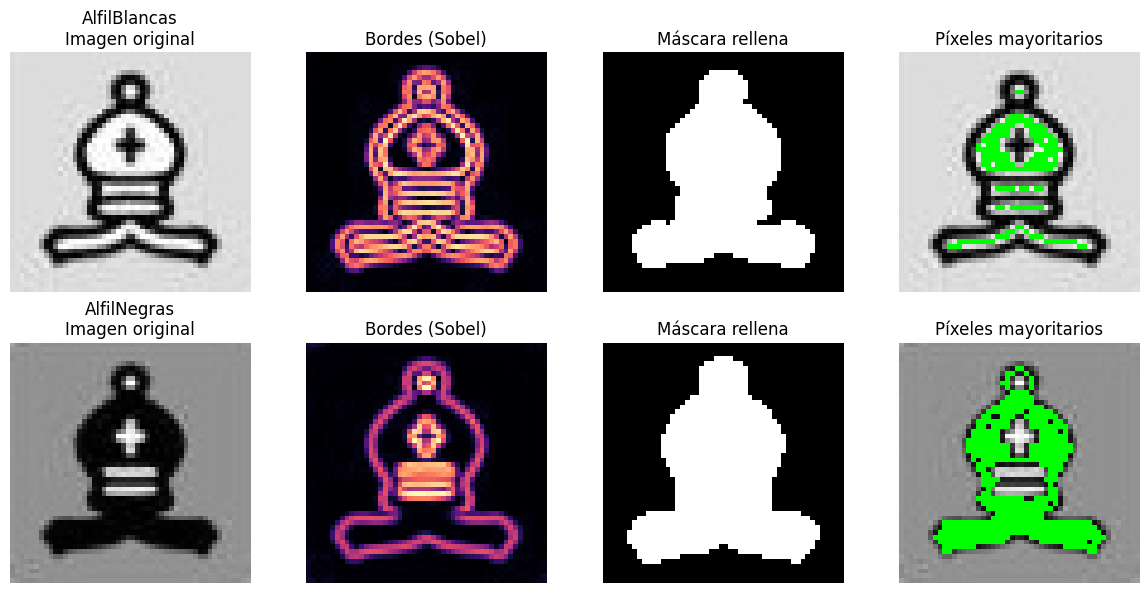

In [7]:
piezas = [("AlfilBlancas", AlfilBlancas), ("AlfilNegras", AlfilNegras)]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for fila, (nombre, pieza) in enumerate(piezas):
    edges, mask, selected_mask, _ = preprocess_image(pieza, return_all_steps=True)

    img_mayoritarios = np.zeros_like(pieza)
    img_mayoritarios[selected_mask] = pieza[selected_mask]

    # Columna 0: original
    axs[fila, 0].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    axs[fila, 0].set_title(f'{nombre}\nImagen original')
    axs[fila, 0].axis('off')

    # Columna 1: bordes
    axs[fila, 1].imshow(edges, cmap='magma')
    axs[fila, 1].set_title('Bordes (Sobel)')
    axs[fila, 1].axis('off')

    # Columna 2: máscara
    axs[fila, 2].imshow(mask, cmap='gray')
    axs[fila, 2].set_title('Máscara rellena')
    axs[fila, 2].axis('off')

    # Columna 3: overlay píxeles mayoritarios
    axs[fila, 3].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    alpha_mask = selected_mask.astype(float)
    green_overlay = np.zeros((*pieza.shape, 4))
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = alpha_mask
    axs[fila, 3].imshow(green_overlay)
    axs[fila, 3].set_title('Píxeles mayoritarios')
    axs[fila, 3].axis('off')

plt.tight_layout()
plt.show()

De esta manera consideraremos solo el color medio de las piezas y obtendremos dos grupos: valor medio superior e inferior (en lugar de los 4 que saldrían si no filtrasemos la parte de las celdas). El grupo inferior lo clasificaremos como piezas blancas y el superior como piezas negras (pudiendo asi clasificar tableros con otros tonos de piezas, como beiges + marrones). 

Hay que darse cuenta de que la máscara sin bordes no es demasiado precisa (y eso de que la torre es una de las piezas más sencillas, pruebese con la dama), pero da mejores resultados que coger la mascara rellena al completo (ya que los bordes son del color opuesto).

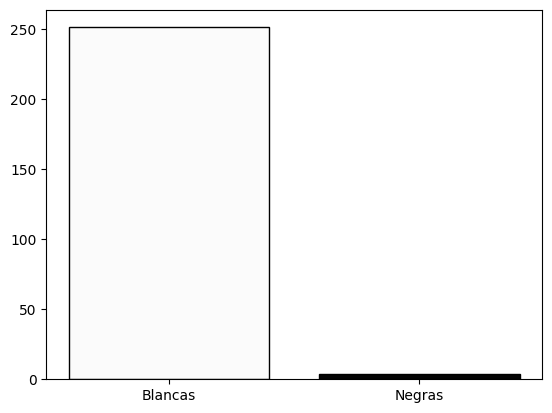

In [8]:
def masked_mean(img, **kwargs):
    '''Returns the mean value of the selected piece pixels in the image'''
    return preprocess_image(img, **kwargs).mean()

blancas = [AlfilBlancas, CaballoBlancas, PeonBlancas, ReinaBlancas, ReyBlancas, TorreBlancas]
negras = [AlfilNegras, CaballoNegras, PeonNegras, ReinaNegras, ReyNegras, TorreNegras]

blancas_mean = np.mean([masked_mean(img) for img in blancas])
negras_mean = np.mean([masked_mean(img) for img in negras])

colores = [
    (np.clip(blancas_mean / 255, 0, 1),) * 3,
    (np.clip(negras_mean / 255, 0, 1),) * 3
]

plt.bar(['Blancas', 'Negras'], [blancas_mean, negras_mean], color=colores, edgecolor='black')
plt.show()

Y las formas:

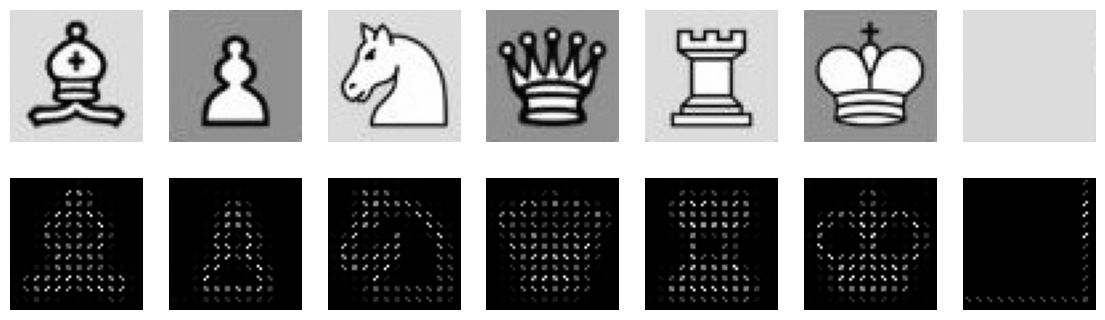

In [9]:
fig, axes = plt.subplots(2, 7, figsize=(14, 4), sharey='row')

pieces = {}
piece_names = ['Alfil', 'Peon', 'Caballo', 'Reina', 'Torre', 'Rey', 'Vacia']

for i, img in enumerate([AlfilBlancas, PeonBlancas, CaballoBlancas, ReinaBlancas, TorreBlancas, ReyBlancas, CeldaVacia1]):
    ax = axes[0, i % 7]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    features, hog_image = hog(
        img,
        orientations=6,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )

    pieces[piece_names[i]] = features

    ax2 = axes[1, i % 7]
    ax2.imshow(hog_image, cmap='gray')
    ax2.axis('off')

## Ventana Deslizante

In [10]:
BOARD_SIZE = 400
SQUARE_SIZE = 50

In [11]:
def hog_closest(image):
    '''Returns the closest piece to the image'''

    features, _ = hog(
        image,
        orientations=6,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True,
    )

    distances = {}
    for piece_name, piece_features in pieces.items():
        distance = np.linalg.norm(features - piece_features)
        distances[piece_name] = distance

    closest_piece = min(distances, key=distances.get)
    return closest_piece

Vamos a comprobar con las piezas negras que nuestro modelo de reconocimiento de formas funciona

In [12]:
assert hog_closest(CaballoNegras) == 'Caballo'
assert hog_closest(ReinaNegras) == 'Reina'
assert hog_closest(CeldaVacia2) == 'Vacia'
assert hog_closest(PeonNegras) == 'Peon'
assert hog_closest(TorreNegras) == 'Torre'
assert hog_closest(AlfilNegras) == 'Alfil'
assert hog_closest(ReyNegras) == 'Rey'

Ahora dividiremos el tablero por casillas y las iremos clasificando. Para que el gráfico quede más limpio, no se etiquetarán las celdas vacías.

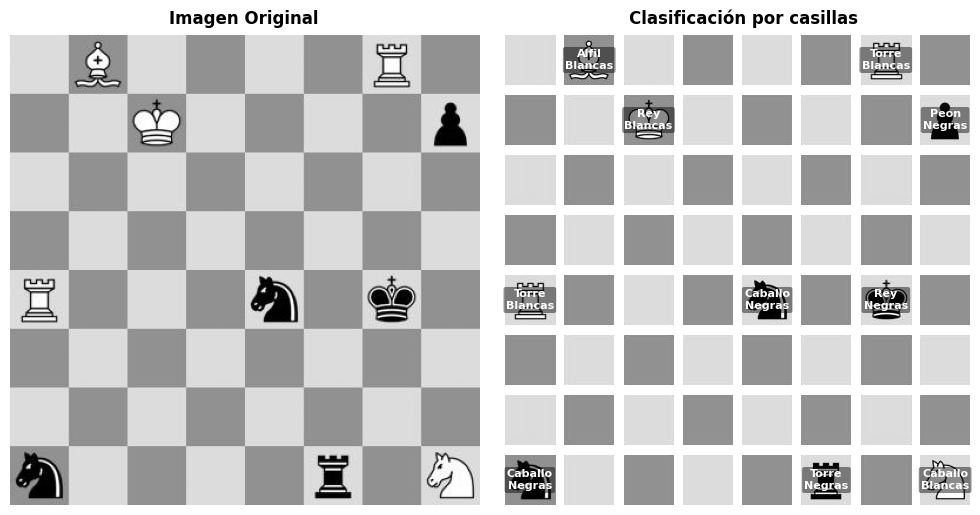

In [13]:
tablero = tableros[1]

fig = plt.figure(figsize=(10, 5))

gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

ax_left = fig.add_subplot(gs[0])
ax_left.imshow(tablero, cmap='gray')
ax_left.axis('off')

fig.text(0.25, 1.02, "Imagen Original", ha='center', va='top', fontsize=12, fontweight='bold')
fig.text(0.75, 1.02, "Clasificación por casillas", ha='center', va='top', fontsize=12, fontweight='bold')

gs_right = gs[1].subgridspec(8, 8)

axes_right = []
for i in range(8):
    row = []
    for j in range(8):
        ax = fig.add_subplot(gs_right[i, j])
        square = tablero[i*SQUARE_SIZE:(i+1)*SQUARE_SIZE, j*SQUARE_SIZE:(j+1)*SQUARE_SIZE]
        piece = hog_closest(square)

        ax.imshow(square, cmap='gray', vmin=0, vmax=255)

        if piece != 'Vacia':
            # Si no es casilla vacía, hay que mirar si es pieza blanca o negra
            masked_mean_value = masked_mean(square)
            if masked_mean_value > 128:
                piece += '\nBlancas'
            else:
                piece += '\nNegras'

            ax.text(
                0.5, 0.5, piece,
                color='white',
                fontsize=8,
                ha='center',
                va='center',
                transform=ax.transAxes,
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, edgecolor='none', boxstyle='round,pad=0.2')
            )
        ax.axis('off')
        row.append(ax)

    axes_right.append(row)

plt.tight_layout()
plt.show()

Ahora, solo queda reconstruir el FEN:

In [14]:
def FEN_constructor(tablero):
    fen = ""
    piece_to_fen = {
                    'Peon': 'p',
                    'Caballo': 'n',
                    'Alfil': 'b',
                    'Torre': 'r',
                    'Reina': 'q',
                    'Rey': 'k'
                }
    
    for i in range(8):
        empty_count = 0
        for j in range(8):
            square = tablero[i*SQUARE_SIZE:(i+1)*SQUARE_SIZE, j*SQUARE_SIZE:(j+1)*SQUARE_SIZE]
            piece = hog_closest(square)

            if piece == 'Vacia':
                empty_count += 1
            else:
                if empty_count > 0:
                    fen += str(empty_count)
                    empty_count = 0

                masked_mean_value = masked_mean(square)
                # Clasifica por cercania a las medias de referencia, en vez de usar umbral fijo
                dist_blancas = abs(masked_mean_value - blancas_mean)
                dist_negras = abs(masked_mean_value - negras_mean)
                color = 'Blancas' if dist_blancas <= dist_negras else 'Negras'

                fen_piece = piece_to_fen[piece]
                fen_piece = fen_piece.upper() if color == 'Blancas' else fen_piece.lower()
                fen += fen_piece

        if empty_count > 0:
            fen += str(empty_count)

        if i < 7:
            fen += "/"

    return fen

In [15]:
for i in range(len(tableros)):
    print("FEN CONSTRUIDO:", FEN_constructor(tableros[i]))
    print("FEN REAL:      ", fen_tableros[i].name.replace(".jpeg", "").replace("-", "/"))
    print("✅ Correcto" if FEN_constructor(tableros[i]) == fen_tableros[i].stem.replace("-", "/") else "❌ Incorrecto", end="\n\n" if i < len(tableros) - 1 else "")

FEN CONSTRUIDO: 1K6/N1PN4/3n4/1qp3Np/B6p/8/3r4/1bk3N1
FEN REAL:       1K6/N1PN4/3n4/1qp3Np/B6p/8/3r4/1bk3N1
✅ Correcto

FEN CONSTRUIDO: 1B4R1/2K4p/8/8/R3n1k1/8/8/n4r1N
FEN REAL:       1B4R1/2K4p/8/8/R3n1k1/8/8/n4r1N
✅ Correcto

FEN CONSTRUIDO: 1b6/2K5/1P6/q7/8/P2k3R/1b6/7B
FEN REAL:       1B6/2K5/1P6/q7/8/P2k3R/1b6/7B
❌ Incorrecto

FEN CONSTRUIDO: 1Q1n4/P7/2P5/1nk5/7q/1K6/1N2qp2/5RN1
FEN REAL:       1Q1n4/P7/2P5/1nk5/7Q/1K6/1N2qp2/5RN1
❌ Incorrecto

FEN CONSTRUIDO: 1b6/3P4/6B1/K7/7k/7b/2R5/2N1b3
FEN REAL:       1b6/3P4/6B1/K7/7k/7b/2R5/2N1b3
✅ Correcto

FEN CONSTRUIDO: 1K6/3B4/rR6/8/3k4/6B1/6q1/5b2
FEN REAL:       1K6/3B4/rR6/8/3k4/6B1/6q1/5b2
✅ Correcto

Como se puede ver, el modelo ha fallado en uno de los fen. En concreto, el modelo ha confundido el tercer y cuarto fen, interpretando un alfíl y una dama blancas como negras. Vamos a dibujar todos los tableros.

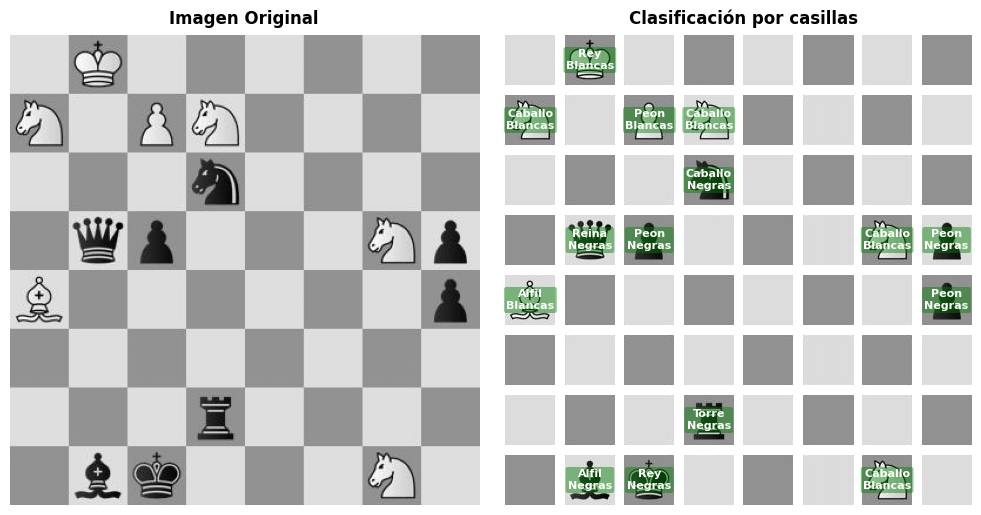

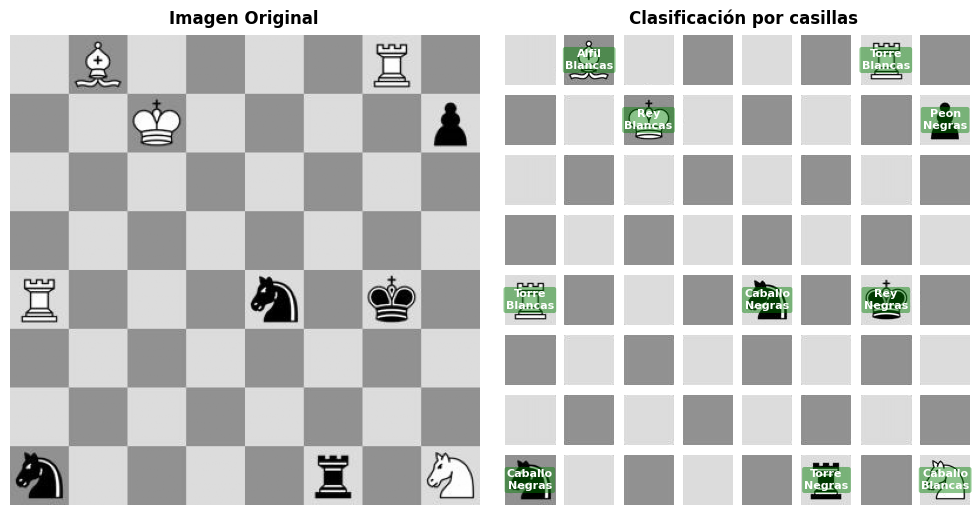

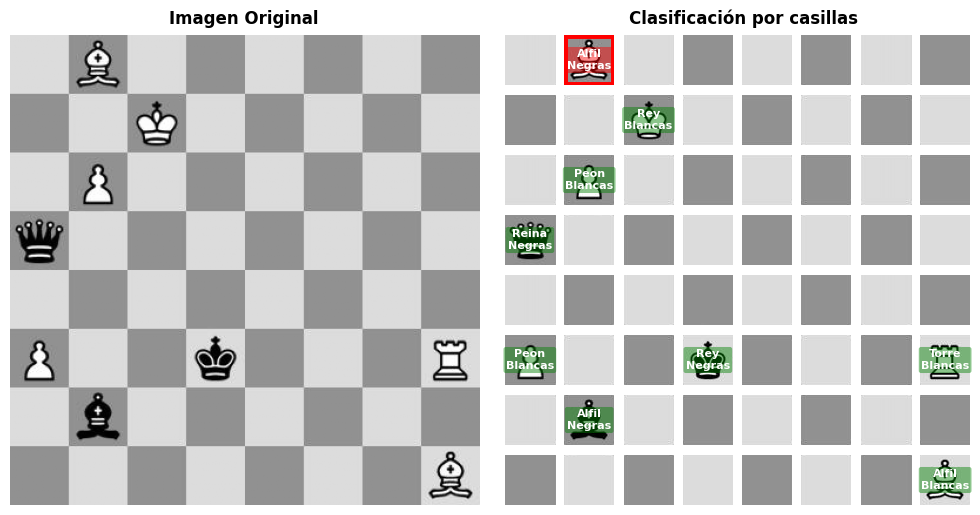

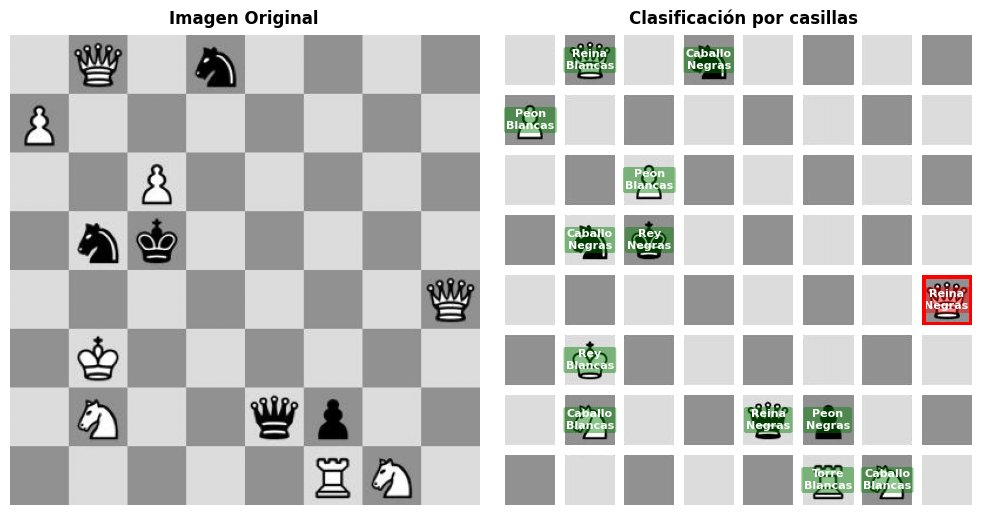

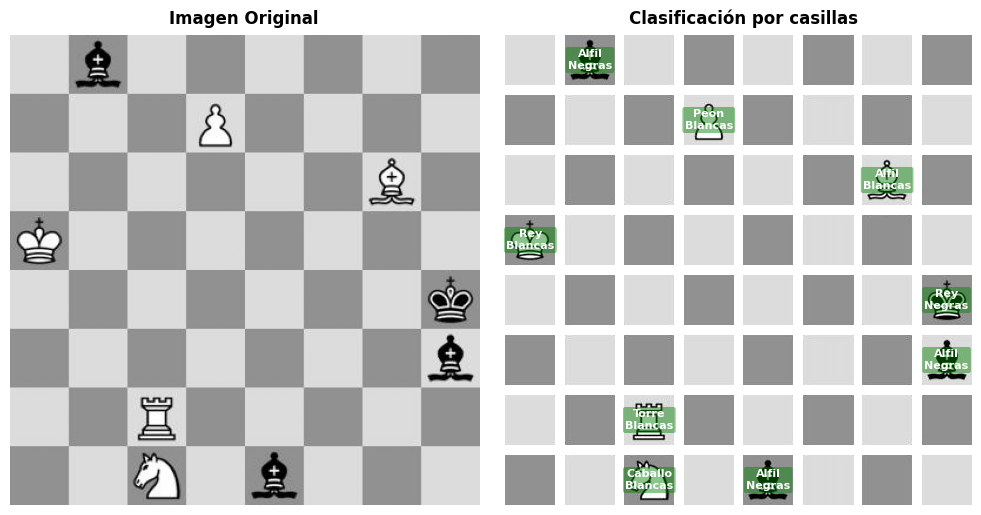

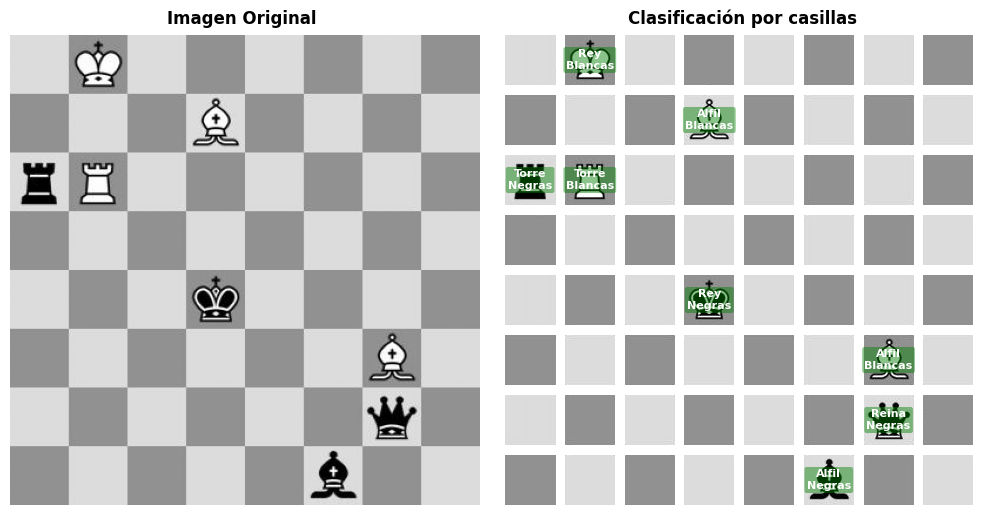

In [16]:
def expand_fen(fen):
    rows = []
    for row in fen.split('/'):
        expanded = []
        for ch in row:
            if ch.isdigit():
                expanded.extend(['1'] * int(ch))
            else:
                expanded.append(ch)
        rows.append(expanded)
    return rows


def grid_to_fen(grid):
    fen_rows = []
    for row in grid:
        fen_row = []
        empty_count = 0
        for ch in row:
            if ch == '1':
                empty_count += 1
            else:
                if empty_count > 0:
                    fen_row.append(str(empty_count))
                    empty_count = 0
                fen_row.append(ch)
        if empty_count > 0:
            fen_row.append(str(empty_count))
        fen_rows.append(''.join(fen_row))
    return '/'.join(fen_rows)


piece_to_fen = {
    'Peon': 'p',
    'Caballo': 'n',
    'Alfil': 'b',
    'Torre': 'r',
    'Reina': 'q',
    'Rey': 'k'
}

for board_idx, tablero in enumerate(tableros):
    expected_fen = fen_tableros[board_idx].stem.replace('-', '/')
    expected_grid = expand_fen(expected_fen)
    predicted_grid = []

    fig = plt.figure(figsize=(10, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

    ax_left = fig.add_subplot(gs[0])
    ax_left.imshow(tablero, cmap='gray')
    ax_left.axis('off')

    fig.text(0.25, 1.02, 'Imagen Original', ha='center', va='top', fontsize=12, fontweight='bold')
    fig.text(0.75, 1.02, 'Clasificación por casillas', ha='center', va='top', fontsize=12, fontweight='bold')

    gs_right = gs[1].subgridspec(8, 8)

    for i in range(8):
        pred_row = []
        for j in range(8):
            ax = fig.add_subplot(gs_right[i, j])
            square = tablero[i * SQUARE_SIZE:(i + 1) * SQUARE_SIZE, j * SQUARE_SIZE:(j + 1) * SQUARE_SIZE]
            piece = hog_closest(square)

            ax.imshow(square, cmap='gray', vmin=0, vmax=255)

            if piece == 'Vacia':
                fen_char = '1'
            else:
                masked_mean_value = masked_mean(square)
                color = 'Blancas' if masked_mean_value > 128 else 'Negras'
                fen_char = piece_to_fen[piece].upper() if color == 'Blancas' else piece_to_fen[piece]

            pred_row.append(fen_char)
            is_correct = fen_char == expected_grid[i][j]

            if piece != 'Vacia':
                label_bg = 'green' if is_correct else 'red'
                ax.text(
                    0.5, 0.5, f'{piece}\n{color}',
                    color='white',
                    fontsize=8,
                    ha='center',
                    va='center',
                    transform=ax.transAxes,
                    fontweight='bold',
                    bbox=dict(facecolor=label_bg, alpha=0.45, edgecolor='none', boxstyle='round,pad=0.2')
                )

            if not is_correct:
                # Resalta en rojo las casillas incorrectas
                ax.add_patch(
                    Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='red', linewidth=5, zorder=10)
                )

            ax.axis('off')

        predicted_grid.append(pred_row)

    predicted_fen = grid_to_fen(predicted_grid)

    plt.tight_layout()
    plt.show()

Como los errores son por color, vamos a comprobar el pipeline de clasificación de color para estas piezas.

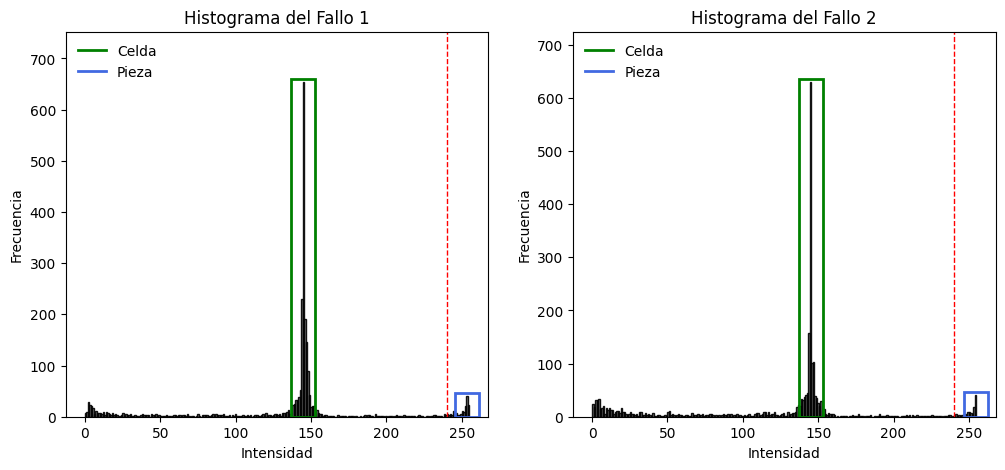

In [17]:
fallo_1 = tableros[2][0:50, 50:100]
fallo_2 = tableros[3][200:250, 350:400]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_b, bin_edges_b, _ = axes[0].hist(fallo_1.ravel(), bins=256, color='dimgray', edgecolor='black', alpha=0.9)
axes[0].axvline(treshold_blancas, color='red', linestyle='dashed', linewidth=1)
axes[0].set_title('Histograma del Fallo 1')
axes[0].set_xlabel('Intensidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_ylim(0, max(counts_b) * 1.15)

peak_order_b = np.argsort(counts_b)[::-1]
cell_peak_b = peak_order_b[0]
piece_peak_b = next((idx for idx in peak_order_b[1:] if abs(idx - cell_peak_b) > 10), peak_order_b[1])
cell_x_b = (bin_edges_b[cell_peak_b] + bin_edges_b[cell_peak_b + 1]) / 2
piece_x_b = (bin_edges_b[piece_peak_b] + bin_edges_b[piece_peak_b + 1]) / 2
cell_y_b = counts_b[cell_peak_b]
piece_y_b = counts_b[piece_peak_b]
axes[0].add_patch(Rectangle((cell_x_b - 8, 0), width=16, height=cell_y_b + 6, fill=False, edgecolor='green', linewidth=2))
axes[0].add_patch(Rectangle((piece_x_b - 8, 0), width=16, height=piece_y_b + 6, fill=False, edgecolor='royalblue', linewidth=2))

counts_n, bin_edges_n, _ = axes[1].hist(fallo_2.ravel(), bins=256, color='dimgray', edgecolor='black', alpha=0.9)
axes[1].axvline(treshold_blancas, color='red', linestyle='dashed', linewidth=1)
axes[1].set_title('Histograma del Fallo 2')
axes[1].set_xlabel('Intensidad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_ylim(0, max(counts_n) * 1.15)

peak_order_n = np.argsort(counts_n)[::-1]
cell_peak_n = peak_order_n[0]
piece_peak_n = next((idx for idx in peak_order_n[1:] if abs(idx - cell_peak_n) > 10), peak_order_n[1])
cell_x_n = (bin_edges_n[cell_peak_n] + bin_edges_n[cell_peak_n + 1]) / 2
piece_x_n = (bin_edges_n[piece_peak_n] + bin_edges_n[piece_peak_n + 1]) / 2
cell_y_n = counts_n[cell_peak_n]
piece_y_n = counts_n[piece_peak_n]
axes[1].add_patch(Rectangle((cell_x_n - 8, 0), width=16, height=cell_y_n + 6, fill=False, edgecolor='green', linewidth=2))
axes[1].add_patch(Rectangle((piece_x_n - 8, 0), width=16, height=piece_y_n + 6, fill=False, edgecolor='royalblue', linewidth=2))

legend_handles = [
    Line2D([0], [0], color='green', lw=2, label='Celda'),
    Line2D([0], [0], color='royalblue', lw=2, label='Pieza')
]
axes[0].legend(handles=legend_handles, loc='upper left', frameon=False)
axes[1].legend(handles=legend_handles, loc='upper left', frameon=False)

plt.show()

Este histograma revela que en estas figuras, el borde de las piezas blancas esta haciendo que nuestro modelo de clasificación de color falle (al ser este negro y grueso). 

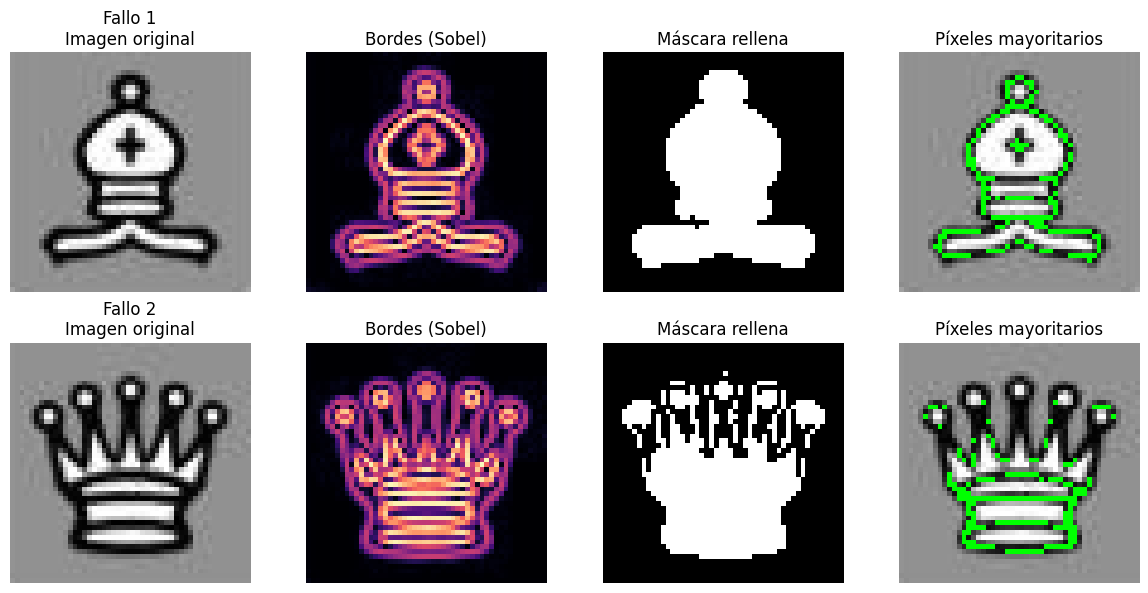

In [18]:
piezas = [("Fallo 1", fallo_1), ("Fallo 2", fallo_2)]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for fila, (nombre, pieza) in enumerate(piezas):
    edges, mask, selected_mask, _ = preprocess_image(pieza, return_all_steps=True)

    img_mayoritarios = np.zeros_like(pieza)
    img_mayoritarios[selected_mask] = pieza[selected_mask]

    # Columna 0: original
    axs[fila, 0].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    axs[fila, 0].set_title(f'{nombre}\nImagen original')
    axs[fila, 0].axis('off')

    # Columna 1: bordes
    axs[fila, 1].imshow(edges, cmap='magma')
    axs[fila, 1].set_title('Bordes (Sobel)')
    axs[fila, 1].axis('off')

    # Columna 2: máscara
    axs[fila, 2].imshow(mask, cmap='gray')
    axs[fila, 2].set_title('Máscara rellena')
    axs[fila, 2].axis('off')

    # Columna 3: overlay píxeles mayoritarios
    axs[fila, 3].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    alpha_mask = selected_mask.astype(float)
    green_overlay = np.zeros((*pieza.shape, 4))
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = alpha_mask
    axs[fila, 3].imshow(green_overlay)
    axs[fila, 3].set_title('Píxeles mayoritarios')
    axs[fila, 3].axis('off')

plt.tight_layout()
plt.show()

Como anticipábamos, el modelo se esta quedando con los bordes en lugar de con el color principal. Vamos a probar a modificar el treshold:

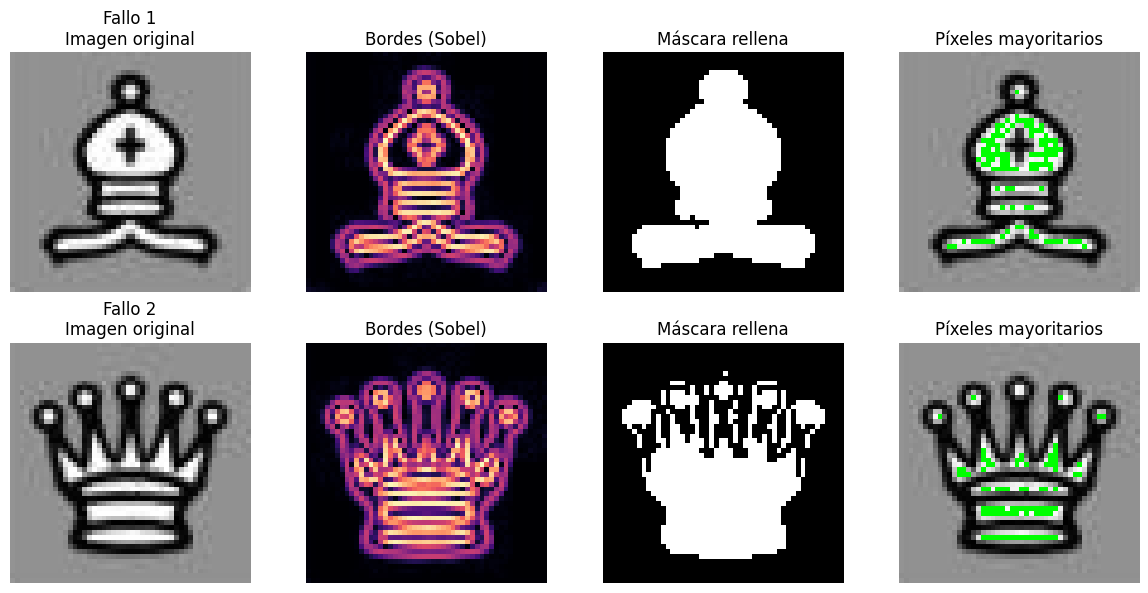

In [19]:
piezas = [("Fallo 1", fallo_1), ("Fallo 2", fallo_2)]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))

for fila, (nombre, pieza) in enumerate(piezas):
    edges, mask, selected_mask, _ = preprocess_image(pieza, return_all_steps=True, treshold_blancas=250, treshold_negras=5)

    img_mayoritarios = np.zeros_like(pieza)
    img_mayoritarios[selected_mask] = pieza[selected_mask]

    # Columna 0: original
    axs[fila, 0].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    axs[fila, 0].set_title(f'{nombre}\nImagen original')
    axs[fila, 0].axis('off')

    # Columna 1: bordes
    axs[fila, 1].imshow(edges, cmap='magma')
    axs[fila, 1].set_title('Bordes (Sobel)')
    axs[fila, 1].axis('off')

    # Columna 2: máscara
    axs[fila, 2].imshow(mask, cmap='gray')
    axs[fila, 2].set_title('Máscara rellena')
    axs[fila, 2].axis('off')

    # Columna 3: overlay píxeles mayoritarios
    axs[fila, 3].imshow(pieza, cmap='gray', vmin=0, vmax=255)
    alpha_mask = selected_mask.astype(float)
    green_overlay = np.zeros((*pieza.shape, 4))
    green_overlay[..., 1] = 1.0
    green_overlay[..., 3] = alpha_mask
    axs[fila, 3].imshow(green_overlay)
    axs[fila, 3].set_title('Píxeles mayoritarios')
    axs[fila, 3].axis('off')

plt.tight_layout()
plt.show()

Ahora sí estamos cogiendo el interior de la pieza, aunque, a cambio, no estamos cogiendo todos los pixeles blancos que podríamos con un treshold mayor. Veamos si estos nuevos valores permiten clasificar bien todos los tableros:

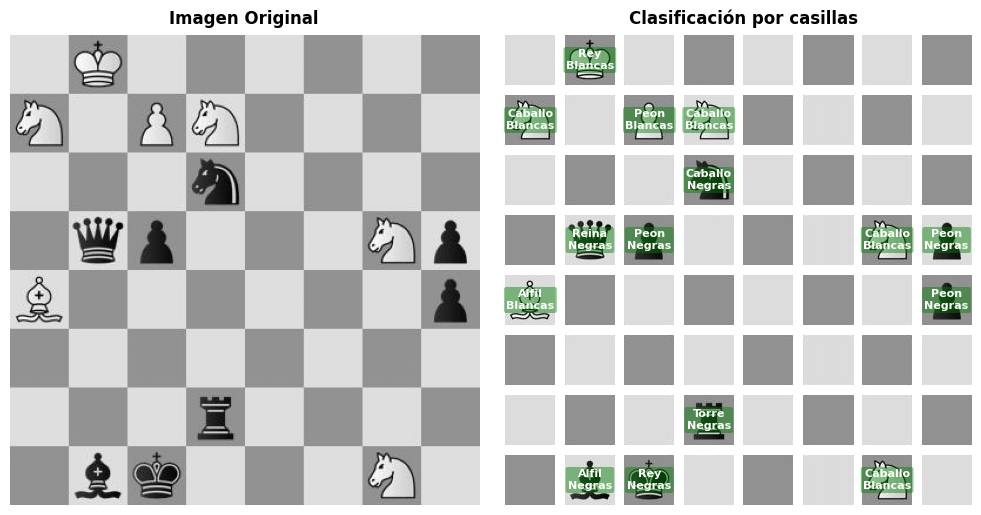

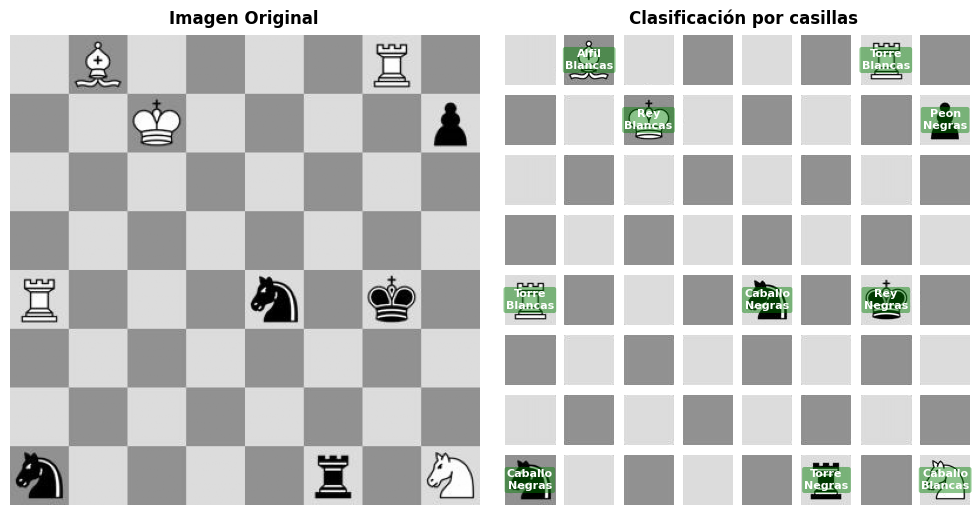

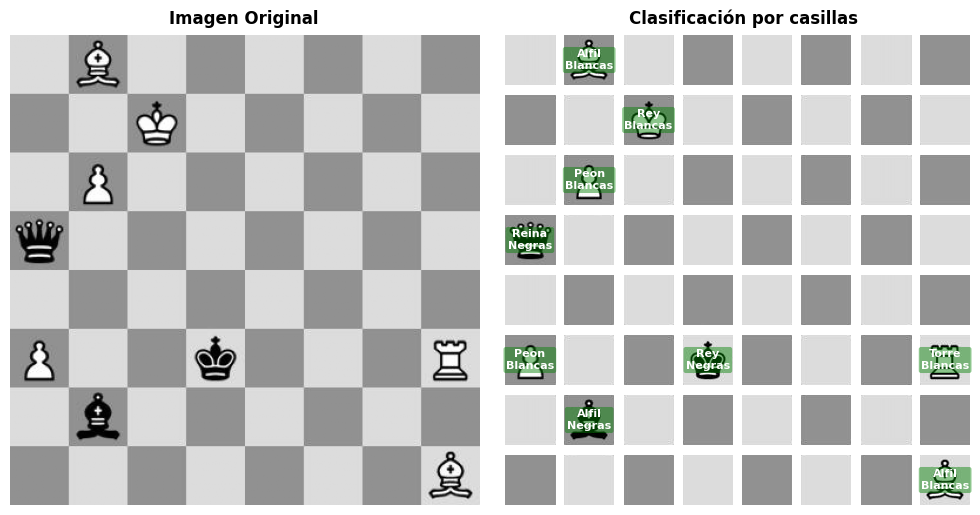

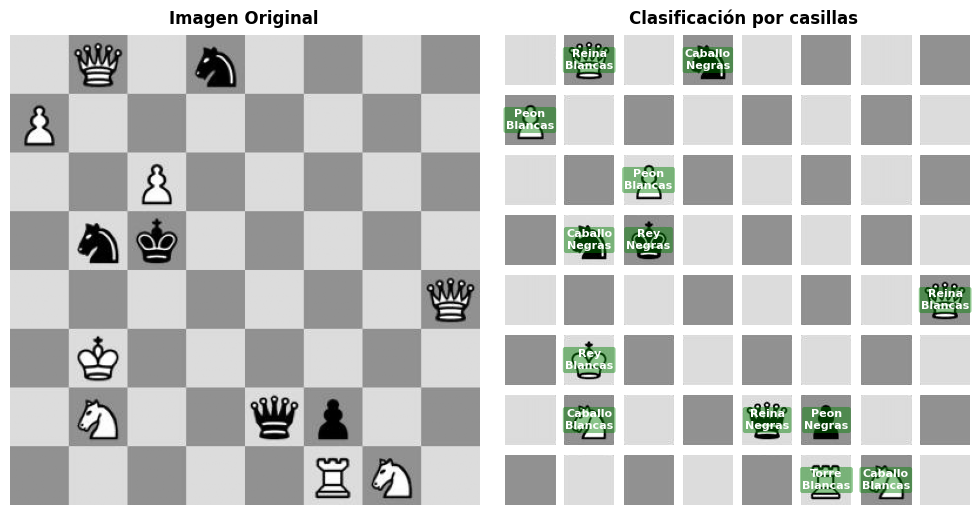

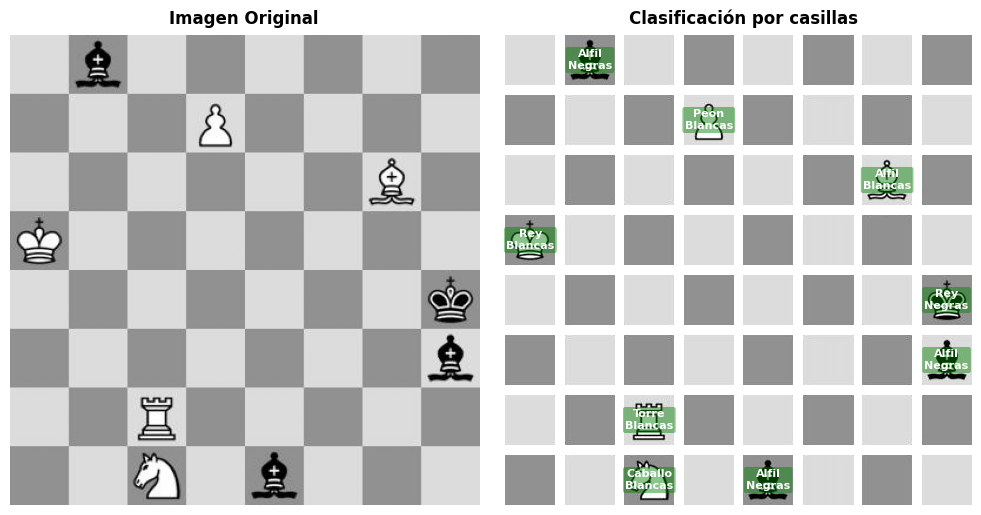

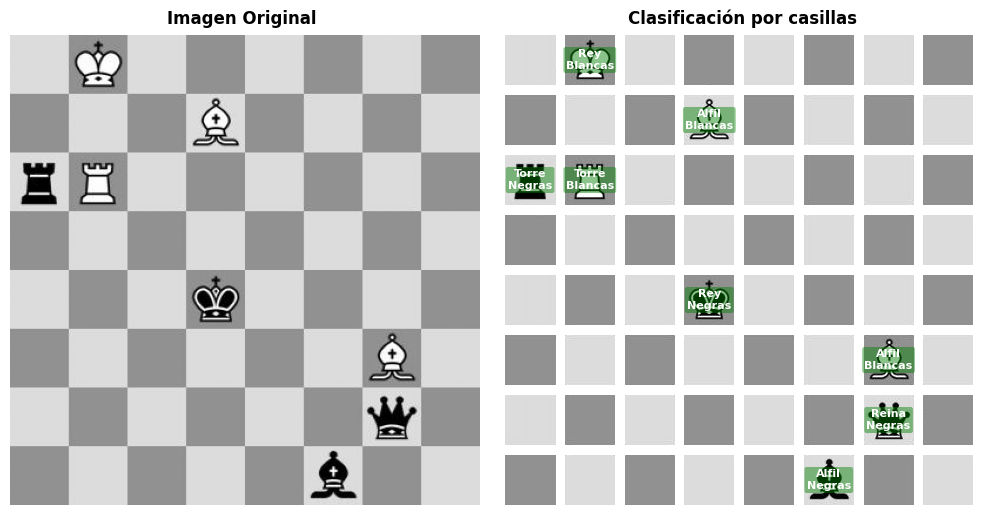

In [20]:
for board_idx, tablero in enumerate(tableros):
    expected_fen = fen_tableros[board_idx].stem.replace('-', '/')
    expected_grid = expand_fen(expected_fen)
    predicted_grid = []

    fig = plt.figure(figsize=(10, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])

    ax_left = fig.add_subplot(gs[0])
    ax_left.imshow(tablero, cmap='gray')
    ax_left.axis('off')

    fig.text(0.25, 1.02, 'Imagen Original', ha='center', va='top', fontsize=12, fontweight='bold')
    fig.text(0.75, 1.02, 'Clasificación por casillas', ha='center', va='top', fontsize=12, fontweight='bold')

    gs_right = gs[1].subgridspec(8, 8)

    for i in range(8):
        pred_row = []
        for j in range(8):
            ax = fig.add_subplot(gs_right[i, j])
            square = tablero[i * SQUARE_SIZE:(i + 1) * SQUARE_SIZE, j * SQUARE_SIZE:(j + 1) * SQUARE_SIZE]
            piece = hog_closest(square)

            ax.imshow(square, cmap='gray', vmin=0, vmax=255)

            if piece == 'Vacia':
                fen_char = '1'
            else:
                masked_mean_value = masked_mean(square, treshold_blancas=250, treshold_negras=5)
                color = 'Blancas' if masked_mean_value > 128 else 'Negras'
                fen_char = piece_to_fen[piece].upper() if color == 'Blancas' else piece_to_fen[piece]

            pred_row.append(fen_char)
            is_correct = fen_char == expected_grid[i][j]

            if piece != 'Vacia':
                label_bg = 'green' if is_correct else 'red'
                ax.text(
                    0.5, 0.5, f'{piece}\n{color}',
                    color='white',
                    fontsize=8,
                    ha='center',
                    va='center',
                    transform=ax.transAxes,
                    fontweight='bold',
                    bbox=dict(facecolor=label_bg, alpha=0.45, edgecolor='none', boxstyle='round,pad=0.2')
                )

            if not is_correct:
                # Resalta en rojo las casillas incorrectas
                ax.add_patch(
                    Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='red', linewidth=5, zorder=10)
                )

            ax.axis('off')

        predicted_grid.append(pred_row)

    predicted_fen = grid_to_fen(predicted_grid)

    plt.tight_layout()
    plt.show()

Finalmente, se ha conseguido que el sistema no cometa errores en la clasificación final de las piezas. Dado que las piezas presentan una morfología sencilla y bien diferenciada, ha sido suficiente emplear una estrategia basada en la comparación de descriptores HOG mediante medidas de distancia.

En cuanto a la detección del color, el proceso ha resultado algo más delicado debido al ruido presente en las imágenes. Esto ha obligado a ajustar umbrales bastante restrictivos para poder diferenciar correctamente entre piezas blancas y negras. Como los bordes eran gruesos y de color negro, interferían en la clasificación del color. Como consecuencia, ciertas piezas blancas se clasificaban erróneamente como negras. Este inconveniente se ha resuelto afinando el criterio de decisión, logrando finalmente una discriminación fiable entre ambos colores. No obstante, en escenarios más complejos o con mayor variabilidad en las condiciones de captura, sería necesario emplear técnicas más robustas.